# 01 - Exploratory Data Analysis
### MAI201 MLOps | Group 2 | Customer Churn Prediction

**Purpose:** Understand the raw dataset before any cleaning or modelling. Identify data quality issues, explore the target variable, and find the strongest predictors of churn.

**Dataset:** IBM Telco Customer Churn - [Kaggle source](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

---

| Section | What it covers |
|---|---|
| 1 | Imports and setup |
| 2 | Load the dataset |
| 3 | Column types |
| 4 | Data quality (missing values, duplicates, outliers) |
| 5 | Target variable distribution (class balance) |
| 6 | Churn rate by contract type |
| 7 | Churn rate by tenure |
| 8 | Numeric feature summary |
| 9 | Monthly charges by churn status |
| 9b | Outlier detection |
| 9c | Churn rate by internet service |
| 10 | Categorical feature overview |
| 11 | Summary of findings |


## 1. Imports and Setup

Import all required libraries and define the file paths used throughout the notebook.
- `pandas` loads and manipulates tabular data
- `matplotlib` creates and saves plots
- `Path` handles file paths across Mac, Windows, and Linux without breaking

`%matplotlib inline` tells Jupyter to render plots directly inside the notebook instead of opening a separate window.


In [36]:
import warnings
warnings.filterwarnings("ignore")  # suppress noisy matplotlib warnings

from pathlib import Path            # cross-platform file path handling
import pandas as pd                 # data loading and manipulation
import matplotlib.pyplot as plt     # plotting library
import matplotlib.ticker as mtick   # axis formatting helpers

# render plots inside the notebook cells
%matplotlib inline

# display settings for all plots in this notebook
plt.rcParams["figure.dpi"]     = 110
plt.rcParams["figure.figsize"] = (9, 4)

# path to the raw CSV - uses ../ because the notebook is inside notebooks/
# and the data lives one level up in data/raw/
DATA_PATH = Path("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")


# folder where all EDA plots will be saved as PNG files
PLOTS_DIR = Path("../reports/eda_plots")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)  # create the folder if it does not exist

print("Setup complete.")
print(f"Data path : {DATA_PATH}")
print(f"Plots dir : {PLOTS_DIR}")


Setup complete.
Data path : ../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv
Plots dir : ../reports/eda_plots


## 2. Load the Dataset

Load the raw CSV into a pandas DataFrame and print a quick shape check.
A DataFrame is a table where each row is a customer and each column is a feature.


In [37]:
# read the CSV file from disk into memory as a pandas DataFrame
df = pd.read_csv(DATA_PATH)

print(f"Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

# preview the first 5 rows to confirm the data loaded correctly
df.head()


Shape  : 7,043 rows x 21 columns
Memory : 7975.1 KB


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Column Types

Check the data type of every column.
- `object` means text (string)
- `int64` means whole number
- `float64` means decimal number

**Known issue to spot here:** `TotalCharges` should be a float but will show as `object`.
This is because the raw file stores it as a string. We fix this in `prepare.py`.


In [38]:
# dtypes shows the data type pandas assigned to each column when reading the CSV
df.dtypes


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## 4. Data Quality Assessment

Check for three common data problems before modelling:
1. **Missing values** - columns where some rows have no data
2. **Duplicates** - identical rows that would bias the model
3. **Type errors** - columns stored in the wrong format (e.g. numbers stored as strings)

The rubric specifically requires documenting missing values, duplicates, and outliers.
Outliers are covered in Section 9b.


In [39]:
# isnull() returns True for every missing cell; sum() counts them per column
print("Null counts per column:")
print(df.isnull().sum())

# duplicated() returns True for every row that is an exact copy of a previous row
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Special check: TotalCharges blank strings are NOT caught by isnull()
# because pandas reads blank strings as empty text, not as NaN (missing values)
blank_tc = (df["TotalCharges"].astype(str).str.strip() == "").sum()
print(f"\nTotalCharges blank strings (hidden missing values): {blank_tc}")
print("  All 11 belong to customers with tenure = 0 (brand new customers).")
print("  They have not been billed yet so their total charge is 0.")
print("  Fix in prepare.py: pd.to_numeric(errors='coerce'), then fillna(0.0)")


Null counts per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0

TotalCharges blank strings (hidden missing values): 11
  All 11 belong to customers with tenure = 0 (brand new customers).
  They have not been billed yet so their total charge is 0.
  Fix in prepare.py: pd.to_numeric(errors='coerce'), then fillna(0.0)


### Data Quality Summary

| Issue | Count | Fix in prepare.py |
|---|---|---|
| TotalCharges stored as string (object) | All rows | `pd.to_numeric(errors='coerce')` |
| TotalCharges blank strings (new customers, tenure=0) | 11 rows | `fillna(0.0)` |
| customerID column - row identifier, not a feature | n/a | Drop the column |
| Null values | 0 | No action needed |
| Duplicate rows | 0 | No action needed |

**Conclusion:** The dataset is clean except for the TotalCharges type issue and the customerID column. Both are straightforward to fix.


## 5. Target Variable: Churn

The target variable is `Churn` - whether a customer left the service (Yes) or stayed (No).
Understanding the class balance is important before choosing a model and evaluation metric.

**Why class balance matters:**
If a dataset has 95% of one class, a model that always predicts that class gets 95% accuracy
without learning anything useful. We check the balance here so we can handle it in `train.py`.


In [40]:
# value_counts() counts how many times each value appears in the Churn column
counts = df["Churn"].value_counts()

# normalize=True returns proportions (fractions) instead of raw counts
pcts = df["Churn"].value_counts(normalize=True) * 100

print(f"No churn : {counts['No']:,}  ({pcts['No']:.1f}%)")
print(f"Churned  : {counts['Yes']:,}  ({pcts['Yes']:.1f}%)")
print()
print("The dataset is moderately imbalanced at 73.5% / 26.5%.")
print("This is not extreme, but needs handling.")
print("  Fix in train.py   : class_weight='balanced'")
print("  Primary metric    : ROC-AUC (more robust to imbalance than accuracy)")


No churn : 5,174  (73.5%)
Churned  : 1,869  (26.5%)

The dataset is moderately imbalanced at 73.5% / 26.5%.
This is not extreme, but needs handling.
  Fix in train.py   : class_weight='balanced'
  Primary metric    : ROC-AUC (more robust to imbalance than accuracy)


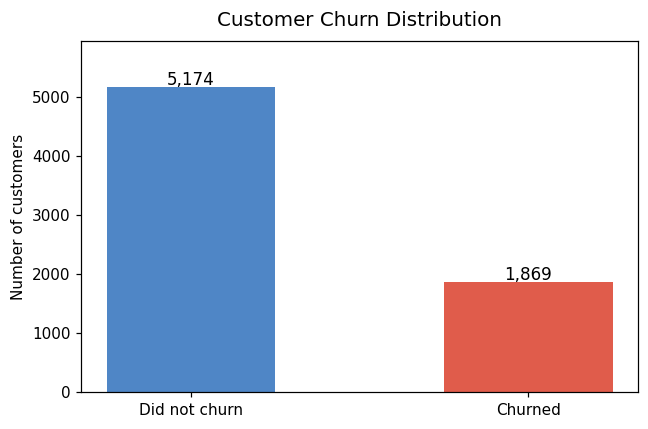

Plot saved: ../reports/eda_plots/01_churn_distribution.png


In [41]:
fig, ax = plt.subplots(figsize=(6, 4))

# .tolist() converts the pandas array to a plain Python list
# matplotlib requires a plain numeric list for the bar heights
bars = ax.bar(
    ["Did not churn", "Churned"],
    counts.values.tolist(),
    color=["#4f86c6", "#e05c4b"],
    width=0.5,
)

# add the count as a label above each bar
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x: centre of the bar
        h + 30,                               # y: just above the bar
        f"{int(h):,}",                        # label text with thousands comma
        ha="center", fontsize=11,
    )

ax.set_title("Customer Churn Distribution", fontsize=13, pad=10)
ax.set_ylabel("Number of customers")
ax.set_ylim(0, max(counts.values.tolist()) * 1.15)  # extra space for labels
plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_churn_distribution.png", dpi=120)
plt.show()
print(f"Plot saved: {PLOTS_DIR / '01_churn_distribution.png'}")


## 6. Churn Rate by Contract Type

Contract type is the single strongest predictor in this dataset.
Customers on a month-to-month contract can leave any time with no penalty,
while one-year and two-year customers face early termination fees.


In [42]:
# groupby groups all rows with the same contract type together
# apply runs a function on each group
# (x == "Yes").mean() calculates the fraction of churners in each group
churn_by_contract = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("Churn rate by contract type:")
for contract, rate in churn_by_contract.items():
    print(f"  {contract:<28}: {rate:.1f}%")


Churn rate by contract type:
  Month-to-month              : 42.7%
  One year                    : 11.3%
  Two year                    : 2.8%


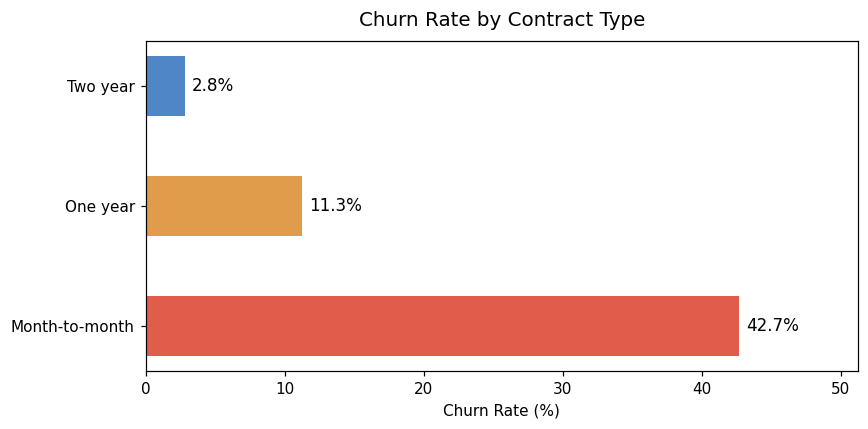

Month-to-month customers churn at ~43%.
Two-year contract customers churn at under 3%.
Contract type is the strongest single predictor of churn.


In [43]:
fig, ax = plt.subplots(figsize=(8, 4))

# barh = horizontal bar chart (easier to read long labels)
bars = ax.barh(
    churn_by_contract.index.tolist(),
    churn_by_contract.values.tolist(),
    color=["#e05c4b", "#e09b4b", "#4f86c6"],
    height=0.5,
)

# add percentage label at the end of each bar
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{w:.1f}%", va="center", fontsize=11)

ax.set_xlabel("Churn Rate (%)")
ax.set_title("Churn Rate by Contract Type", fontsize=13, pad=10)
ax.set_xlim(0, max(churn_by_contract.values.tolist()) * 1.2)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_churn_by_contract.png", dpi=120)
plt.show()

print("Month-to-month customers churn at ~43%.")
print("Two-year contract customers churn at under 3%.")
print("Contract type is the strongest single predictor of churn.")


## 7. Churn Rate by Tenure

Tenure is the number of months a customer has been with the company.
It is the second-strongest predictor after contract type.
New customers are much more likely to churn than long-term customers.

`pd.cut()` divides the continuous tenure values into four labelled brackets
so we can compare churn rates across groups rather than individual month values.


In [44]:
# pd.cut() splits tenure into 4 buckets and assigns a readable label to each
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],                            # bucket boundaries
    labels=["0-12 mo", "13-24 mo", "25-48 mo", "49-72 mo"]  # readable names
)

churn_by_tenure = (
    df.groupby("tenure_group", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print("Churn rate by tenure bracket:")
for group, rate in churn_by_tenure.items():
    print(f"  {str(group):<14}: {rate:.1f}%")

print()
print("New customers (0-12 months) churn at ~48% - nearly 1 in 2.")
print("Long-term customers (49-72 months) churn at only ~9%.")


Churn rate by tenure bracket:
  0-12 mo       : 47.7%
  13-24 mo      : 28.7%
  25-48 mo      : 20.4%
  49-72 mo      : 9.5%

New customers (0-12 months) churn at ~48% - nearly 1 in 2.
Long-term customers (49-72 months) churn at only ~9%.


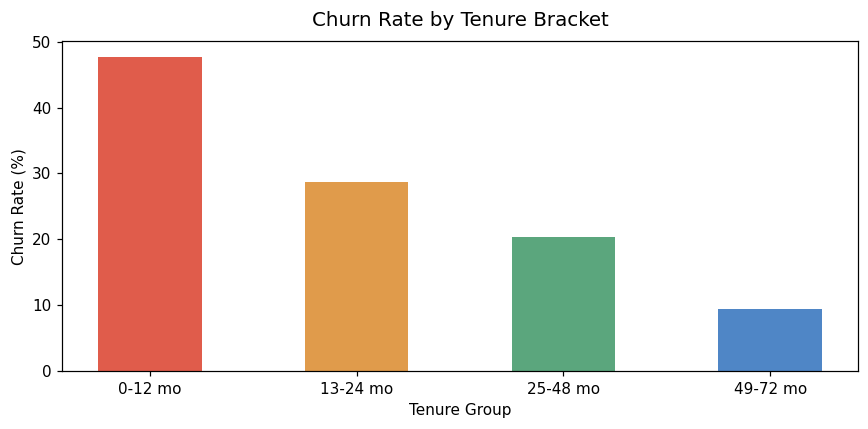

Plot saved: ../reports/eda_plots/03_churn_by_tenure.png


In [45]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(
    [str(g) for g in churn_by_tenure.index],  # convert categorical labels to strings
    churn_by_tenure.values.tolist(),
    color=["#e05c4b", "#e09b4b", "#5ba67d", "#4f86c6"],
    width=0.5,
)

ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("Tenure Group")
ax.set_title("Churn Rate by Tenure Bracket", fontsize=13, pad=10)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_churn_by_tenure.png", dpi=120)
plt.show()
print(f"Plot saved: {PLOTS_DIR / '03_churn_by_tenure.png'}")


## 8. Numeric Feature Summary

There are three numeric features in this dataset: `tenure`, `MonthlyCharges`, and `TotalCharges`.

`describe()` returns count, mean, standard deviation, min, max, and quartiles for each column.
This helps identify scale differences - a key reason StandardScaler is needed before training.


In [46]:
# convert TotalCharges to float first so describe() works correctly
# errors='coerce' turns blank strings into NaN instead of crashing
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# describe() gives a statistical summary of each numeric column
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().round(2)


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


**Key observations:**
- `tenure` ranges from 0 to 72 months
- `MonthlyCharges` ranges from \$18 to \$119
- `TotalCharges` ranges from \$0 to \$8,684

The large range differences mean higher-value features could dominate the model if left unscaled.
`StandardScaler` in `train.py` converts every column to mean=0 and std=1 to fix this.


## 9. Monthly Charges by Churn Status

Compare the monthly charge distributions between customers who churned and those who stayed.
Churned customers tend to have higher bills, suggesting price sensitivity as a churn driver.


In [47]:
# filter the DataFrame into two groups based on the Churn column
churned     = df[df["Churn"] == "Yes"]["MonthlyCharges"]
not_churned = df[df["Churn"] == "No"]["MonthlyCharges"]

print(f"Average monthly charges -- churned    : ${churned.mean():.2f}")
print(f"Average monthly charges -- not churned: ${not_churned.mean():.2f}")
print(f"Difference                            : ${churned.mean() - not_churned.mean():.2f}/month")


Average monthly charges -- churned    : $74.44
Average monthly charges -- not churned: $61.27
Difference                            : $13.18/month


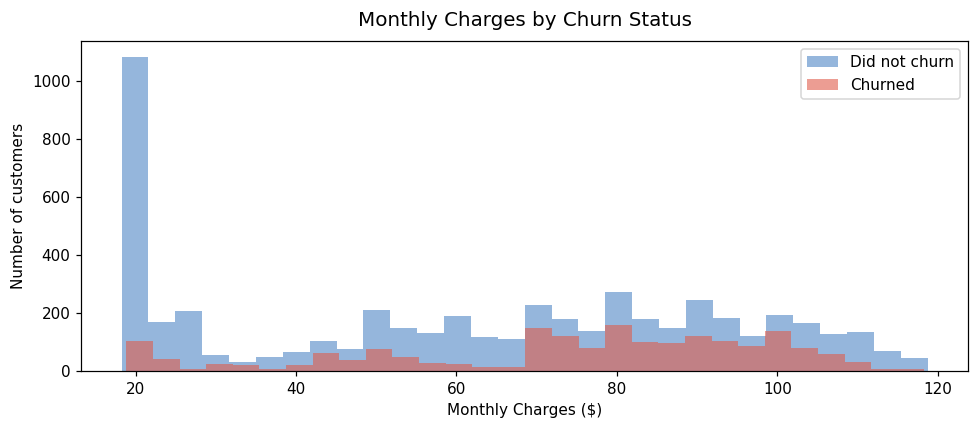

Plot saved: ../reports/eda_plots/04_monthly_charges.png


In [48]:
fig, ax = plt.subplots(figsize=(9, 4))

# overlay two histograms on the same axes with partial transparency (alpha)
# so both distributions are visible where they overlap
ax.hist(not_churned, bins=30, alpha=0.6, label="Did not churn", color="#4f86c6")
ax.hist(churned,     bins=30, alpha=0.6, label="Churned",       color="#e05c4b")

ax.set_xlabel("Monthly Charges ($)")
ax.set_ylabel("Number of customers")
ax.set_title("Monthly Charges by Churn Status", fontsize=13, pad=10)
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_monthly_charges.png", dpi=120)
plt.show()
print(f"Plot saved: {PLOTS_DIR / '04_monthly_charges.png'}")


## 9b. Outlier Detection

The rubric requires checking for outliers. A box plot shows the distribution of each
numeric column and highlights any extreme values that sit far outside the normal range.

**How to read a box plot:**
- The box spans the middle 50% of values (25th to 75th percentile)
- The line inside the box is the median
- The whiskers extend to 1.5x the interquartile range
- Individual dots beyond the whiskers are potential outliers

We split by churn status to check whether outliers are concentrated in one group.


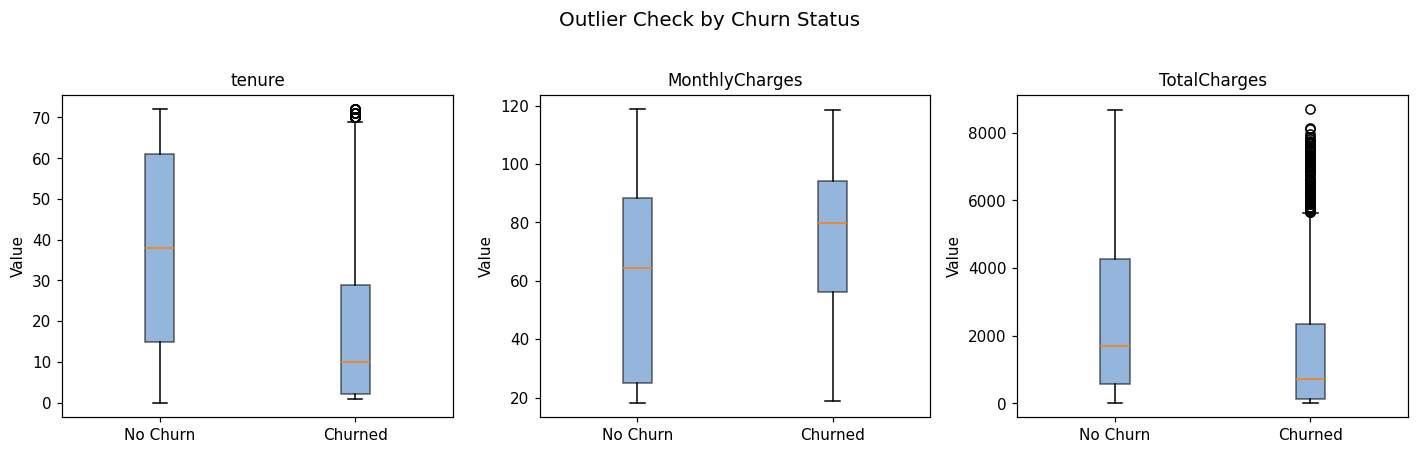

tenure        : max 72 months, min 0. No extreme outliers.
MonthlyCharges: max $118.75. Wide range but all valid billing amounts.
TotalCharges  : max $8,684. Reflects long-tenure, high-spend customers.
Conclusion    : No values require removal. The range reflects real customer variation.


In [49]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    # split each column into two groups: churned and not churned
    churned_vals     = df[df["Churn"] == "Yes"][col].dropna()
    not_churned_vals = df[df["Churn"] == "No"][col].dropna()

    ax.boxplot(
        [not_churned_vals, churned_vals],
        labels=["No Churn", "Churned"],
        patch_artist=True,                        # fills the box with colour
        boxprops=dict(facecolor="#4f86c6", alpha=0.6),
    )
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Value")

plt.suptitle("Outlier Check by Churn Status", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "05_outliers.png", dpi=120)
plt.show()

print("tenure        : max 72 months, min 0. No extreme outliers.")
print("MonthlyCharges: max $118.75. Wide range but all valid billing amounts.")
print("TotalCharges  : max $8,684. Reflects long-tenure, high-spend customers.")
print("Conclusion    : No values require removal. The range reflects real customer variation.")


## 9c. Churn Rate by Internet Service

Internet service type is the third-strongest predictor after contract type and tenure.
Fiber optic customers churn at more than twice the rate of DSL customers.

This likely reflects that fiber optic service is more expensive and has more competition,
making those customers more price-sensitive and easier to poach by competitors.


In [50]:
churn_by_internet = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("Churn rate by internet service type:")
for service, rate in churn_by_internet.items():
    print(f"  {service:<20}: {rate:.1f}%")


Churn rate by internet service type:
  Fiber optic         : 41.9%
  DSL                 : 19.0%
  No                  : 7.4%


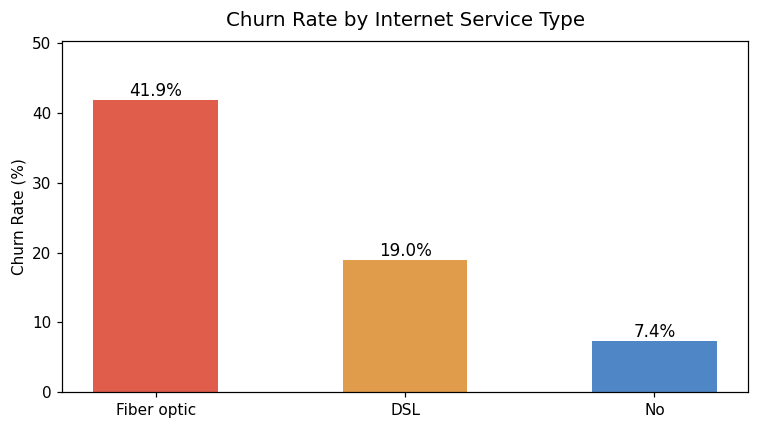

Fiber optic customers churn at ~42% - more than twice the DSL rate.
Customers with no internet service rarely churn (~7%).
InternetService will likely appear as a strong feature in the trained model.


In [51]:
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    churn_by_internet.index.tolist(),   # .tolist() prevents matplotlib type errors
    churn_by_internet.values.tolist(),
    color=["#e05c4b", "#e09b4b", "#4f86c6"],
    width=0.5,
)

# add percentage label above each bar
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, h + 0.5,
        f"{h:.1f}%", ha="center", fontsize=11,
    )

ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Internet Service Type", fontsize=13, pad=10)
ax.set_ylim(0, max(churn_by_internet.values.tolist()) * 1.2)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "06_churn_by_internet.png", dpi=120)
plt.show()

print("Fiber optic customers churn at ~42% - more than twice the DSL rate.")
print("Customers with no internet service rarely churn (~7%).")
print("InternetService will likely appear as a strong feature in the trained model.")


## 10. Categorical Feature Overview

List every categorical column and its unique values. This tells us:
- Which columns are binary (two values) - these use `LabelEncoder` in `prepare.py`
- Which columns have three or more values - these use one-hot encoding in `prepare.py`

One-hot encoding creates a new binary column for each possible value.
For example, `Contract` becomes three columns: `Contract_Month-to-month`, `Contract_One year`, `Contract_Two year`.


In [52]:
# select_dtypes(include='object') returns all text columns
cat_cols = df.select_dtypes(include="object").columns.tolist()

# exclude customerID (will be dropped) and Churn (the target, not a feature)
cat_cols = [c for c in cat_cols if c not in ["customerID", "Churn"]]

print(f"Categorical columns found: {len(cat_cols)}")
print()
for col in cat_cols:
    unique = df[col].unique().tolist()
    print(f"  {col:<20}: {unique}")


Categorical columns found: 15

  gender              : ['Female', 'Male']
  Partner             : ['Yes', 'No']
  Dependents          : ['No', 'Yes']
  PhoneService        : ['No', 'Yes']
  MultipleLines       : ['No phone service', 'No', 'Yes']
  InternetService     : ['DSL', 'Fiber optic', 'No']
  OnlineSecurity      : ['No', 'Yes', 'No internet service']
  OnlineBackup        : ['Yes', 'No', 'No internet service']
  DeviceProtection    : ['No', 'Yes', 'No internet service']
  TechSupport         : ['No', 'Yes', 'No internet service']
  StreamingTV         : ['No', 'Yes', 'No internet service']
  StreamingMovies     : ['No', 'Yes', 'No internet service']
  Contract            : ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling    : ['Yes', 'No']
  PaymentMethod       : ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']


**Encoding plan for `prepare.py`:**

| Type | Columns | Method |
|---|---|---|
| Binary (2 values) | gender, Partner, Dependents, PhoneService, PaperlessBilling | `LabelEncoder` - maps to 0 or 1 |
| Three-value | MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies | `pd.get_dummies` - creates one column per value |
| Multi-category | InternetService, Contract, PaymentMethod | `pd.get_dummies` - creates one column per value |


## 11. Summary of Findings

### Data Quality Issues - fix in `prepare.py`

| Issue | Action |
|---|---|
| `TotalCharges` stored as string | `pd.to_numeric(errors='coerce')` |
| 11 blank `TotalCharges` values (new customers with tenure=0) | `fillna(0.0)` |
| `customerID` column | Drop - it is a row identifier, not a feature |

### Class Imbalance
- 73.5% no churn, 26.5% churned
- Handle with `class_weight='balanced'` in the model
- Use **ROC-AUC** as the primary metric - more robust to imbalance than accuracy

### Strongest Predictors Found in EDA

| Feature | Finding |
|---|---|
| Contract type | Month-to-month customers churn at 43% vs 3% for two-year contracts |
| Tenure | New customers (0-12 months) churn at 48%, long-term at 9% |
| Internet service | Fiber optic customers churn at 42% vs 19% for DSL |
| Monthly charges | Churned customers pay \$13/month more on average |

### Outliers
No outliers require removal. All values in tenure, MonthlyCharges, and TotalCharges
represent valid customer records.

### Performance Targets for Phase 1
- ROC-AUC >= 0.84
- Churn recall >= 0.70


In [53]:
print("EDA complete.")
print(f"Plots saved to: {PLOTS_DIR}")
print()
print("Next steps:")
print("  1. Run prepare.py (or dvc repro) to clean, encode, and split the data")
print("  2. Run train.py to train the baseline model and log results to MLflow")


EDA complete.
Plots saved to: ../reports/eda_plots

Next steps:
  1. Run prepare.py (or dvc repro) to clean, encode, and split the data
  2. Run train.py to train the baseline model and log results to MLflow
